# 03. Deep Research Agent - STORM 기반 멀티 에이전트 연구 시스템

> **왜 Deep Research Agent가 필요한가요?**
>
> 웹 검색 한 번으로 충분한 질문도 있지만, "LangGraph V1의 새로운 기능을 종합적으로 분석해줘" 같은 심층 조사는 **여러 소스를 검색 → 교차 검증 → 종합 분석**하는 다단계 과정이 필요해요. Deep Research Agent는 이 전체 과정을 자동화해요.

> 🔑 **비유**: 일반 검색이 **사전에서 단어 찾기**라면, Deep Research Agent는 **논문 작성을 위한 문헌 조사**예요. 여러 자료를 수집하고, 비교 분석하고, 결론을 도출하는 전체 과정을 수행해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. STORM 논문의 핵심 개념(다양한 관점 인터뷰)을 LangGraph로 구현할 수 있어요
2. Pydantic 모델로 분석가(Analyst) 페르소나를 정의하고 Human-in-the-Loop로 제어할 수 있어요
3. `Send()`를 사용하여 여러 분석가 인터뷰를 병렬(Map-Reduce)로 실행할 수 있어요
4. 웹 검색(Tavily)과 논문 검색(Arxiv)을 병렬로 수행하는 서브그래프를 구성할 수 있어요
5. 서론 · 본문 · 결론을 조립하여 구조화된 연구 보고서를 자동 생성할 수 있어요

## 사전 지식

- LangGraph StateGraph 기초 (Part 2)
- Human-in-the-Loop / interrupt (Part 2, 4)
- Pydantic 구조화 출력 (Part 5)
- Map-Reduce / Send() 패턴 (Part 4, 9)
- 이전 노트북: `02-SQL-Agent.ipynb` (SQL Agent, 자연어→SQL)
- Part 10의 `06-Agent-Harness-Patterns.ipynb`: Delegate / Isolate / Externalize 관점

## STORM 개념과 시스템 아키텍처

이 노트북은 [STORM 논문(Shao et al., 2024)](https://arxiv.org/abs/2402.14207)의 핵심 아이디어를 LangGraph로 구현해요.

**STORM의 핵심 통찰**: 다양한 관점을 가진 분석가가 각자 전문가를 인터뷰하면, 단순 RAG보다 정보 밀도와 소스 활용 빈도가 크게 높아져요.

### 전체 워크플로우

```mermaid
flowchart TD
    A([사용자 입력<br/>연구 주제]) --> B[분석가 생성<br/>create_analysts]
    B --> C{Human-in-the-Loop<br/>human_feedback}
    C -- 피드백 있음 --> B
    C -- 피드백 없음 --> D["병렬 인터뷰 분배<br/>Send() API"]
    D --> E1[인터뷰 1<br/>conduct_interview]
    D --> E2[인터뷰 2<br/>conduct_interview]
    D --> E3[인터뷰 N<br/>conduct_interview]
    E1 & E2 & E3 --> F1[보고서 본문<br/>write_report]
    E1 & E2 & E3 --> F2[서론<br/>write_introduction]
    E1 & E2 & E3 --> F3[결론<br/>write_conclusion]
    F1 & F2 & F3 --> G[최종 보고서<br/>finalize_report]
    G --> H([최종 보고서 출력])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef hitl fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef parallel fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef output fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A input
    class B,F1,F2,F3,G process
    class C hitl
    class D,E1,E2,E3 parallel
    class H output
```

### 인터뷰 서브그래프 (conduct_interview)

```mermaid
flowchart LR
    S([시작]) --> Q[질문 생성<br/>ask_question]
    Q --> W[웹 검색<br/>search_web]
    Q --> X[논문 검색<br/>search_arxiv]
    W & X --> A[답변 생성<br/>answer_question]
    A --> R{라우팅<br/>route_messages}
    R -- 계속 --> Q
    R -- 종료 --> V[인터뷰 저장<br/>save_interview]
    V --> WS[섹션 작성<br/>write_section]
    WS --> E([끝])

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef parallel fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404

    class Q,V,WS process
    class W,X parallel
    class R decision
```

### 주요 구성 요소

| 구성 요소 | 설명 |
|----------|------|
| `Analyst` | 분석가 페르소나 (이름, 역할, 소속, 설명) |
| `Perspectives` | 분석가 목록을 담는 컨테이너 Pydantic 모델 |
| `GenerateAnalystsState` | 분석가 생성 그래프 상태 |
| `InterviewState` | 인터뷰 서브그래프 상태 (MessagesState 확장) |
| `ResearchGraphState` | 전체 연구 워크플로우 상태 |
| `Send()` | 병렬 인터뷰 분배 API |

> 🔑 **핵심 개념**: STORM 시스템은 여러 분석가가 각기 다른 관점에서 인터뷰를 수행하고, 그 결과를 통합하여 보고서를 작성해요. `Send()` API로 모든 인터뷰를 동시에 실행(Map)하고, 완료 후 결과를 모아(Reduce) 최종 보고서를 생성해요.

> 🧭 **Part 10 연결**: 이 노트북은 Deep Agents 철학 중 **Delegate / Isolate / Externalize**를 연구 도메인에 적용한 사례로 읽으면 좋아요. 분석가별 인터뷰는 역할 위임이고, 인터뷰 서브그래프는 격리된 작업 공간이며, 최종 보고서는 대화창 밖으로 외부화되는 산출물이에요.


## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY, TAVILY_API_KEY 등을 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# 모델 초기화
# ---------------------------------------------------
# 기본 모델: gpt-4o-mini (비용 효율적, 학생 접근성 높음)
# 더 높은 품질을 원하면: "openai:gpt-4o" 또는 "anthropic:claude-sonnet-4-5"
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-4o-mini")

## 1. 분석가 페르소나 정의 (Pydantic 모델)

각 분석가는 이름, 역할, 소속, 설명을 가져요. 구조화 출력 문법은 `05_Agent_Development/03-Structured-Output.ipynb`에서 이미 배웠으므로, 여기서는 **STORM 연구 흐름에 필요한 분석가 페르소나 스키마**를 만드는 데 집중합니다.

> 💡 **적용 포인트**: `Perspectives` 모델을 `llm.with_structured_output()`에 전달하면 LLM이 분석가 목록을 자연어가 아니라 검증 가능한 객체 목록으로 반환해요.


In [3]:
# ---------------------------------------------------
# 분석가 페르소나 Pydantic 모델 정의
# ---------------------------------------------------
# Pydantic BaseModel: LLM 구조화 출력에 사용
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field


# 개별 분석가를 표현하는 모델
class Analyst(BaseModel):
    # 소속 기관
    affiliation: str = Field(
        description="Primary affiliation of the analyst.",
    )
    # 이름
    name: str = Field(description="Name of the analyst.")
    # 역할
    role: str = Field(
        description="Role of the analyst in the context of the topic.",
    )
    # 중점, 우려 사항 및 동기
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )

    @property
    def persona(self) -> str:
        """분석가의 페르소나를 하나의 문자열로 반환해요"""
        return (
            f"Name: {self.name}\n"
            f"Role: {self.role}\n"
            f"Affiliation: {self.affiliation}\n"
            f"Description: {self.description}\n"
        )


# 분석가 목록을 담는 컨테이너 모델
class Perspectives(BaseModel):
    # 생성된 분석가들의 목록
    analysts: List[Analyst] = Field(
        description="Comprehensive list of analysts with their roles and affiliations.",
    )


# 모델 확인
print("Analyst 모델 필드:", list(Analyst.model_fields.keys()))

Analyst 모델 필드: ['affiliation', 'name', 'role', 'description']


## 2. 분석가 생성 그래프 (Human-in-the-Loop)

사용자가 연구 주제를 제공하면 LLM이 여러 관점의 분석가를 자동 생성해요. 여기서 HITL은 새 개념 설명이 아니라 **분석가 구성을 사람이 검토하는 적용 사례**입니다.

> 🔁 **복습 연결**: `interrupt_before`, `get_state`, `update_state(as_node=...)` 흐름은 `02_LangGraph_Basics/08-Human-In-The-Loop.ipynb`와 `02_LangGraph_Basics/09-State-Management.ipynb`에서 배웠어요. 이 노트북에서는 그 패턴을 “연구 관점 승인”에 적용합니다.

> ⚠️ **자주 하는 실수**: `human_feedback` 노드는 실제 비즈니스 로직을 실행하지 않고, `interrupt_before` 설정으로 인해 중단점 역할만 해요.


In [4]:
# ---------------------------------------------------
# 분석가 생성 그래프의 상태(State) 정의
# ---------------------------------------------------
# TypedDict: 각 키의 타입을 명시적으로 선언해요

class GenerateAnalystsState(TypedDict):
    # 연구 주제
    topic: str
    # 생성할 분석가의 최대 수
    max_analysts: int
    # 사용자 피드백 (Human-in-the-Loop)
    human_analyst_feedback: str
    # 생성된 분석가 목록
    analysts: List[Analyst]

In [5]:
# ---------------------------------------------------
# 분석가 생성 노드와 라우팅 함수 정의
# ---------------------------------------------------
from langgraph.graph import END
from langchain.messages import HumanMessage, SystemMessage

# 분석가 생성을 위한 시스템 프롬프트
# {topic}, {human_analyst_feedback}, {max_analysts} 자리표시자를 포함해요
analyst_instructions = """You are tasked with creating a set of AI analyst personas. 

Follow these instructions carefully:
1. First, review the research topic:

{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""


def create_analysts(state: GenerateAnalystsState):
    """연구 주제에 대해 다양한 관점의 분석가 페르소나를 생성하는 노드예요"""

    topic = state["topic"]
    max_analysts = state["max_analysts"]
    # 피드백이 없을 수도 있으므로 기본값 설정
    human_analyst_feedback = state.get("human_analyst_feedback", "")

    # LLM에 구조화된 출력 형식(Perspectives)을 적용해요
    structured_llm = llm.with_structured_output(Perspectives)

    # 시스템 프롬프트 구성
    system_message = analyst_instructions.format(
        topic=topic,
        human_analyst_feedback=human_analyst_feedback,
        max_analysts=max_analysts,
    )

    # LLM 호출 → Perspectives 객체 반환
    analysts = structured_llm.invoke(
        [SystemMessage(content=system_message)]
        + [HumanMessage(content="Generate the set of analysts.")]
    )

    return {"analysts": analysts.analysts}


def human_feedback(state: GenerateAnalystsState):
    """Human-in-the-Loop를 위한 중단점 노드예요. 실제 로직은 없어요."""
    # interrupt_before=["human_feedback"]로 그래프가 여기서 멈춰요
    # update_state()로 외부에서 피드백을 주입해요
    pass


def should_continue(state: GenerateAnalystsState):
    """피드백 유무에 따라 다음 노드를 결정하는 라우팅 함수예요"""

    human_analyst_feedback = state.get("human_analyst_feedback", None)
    # 피드백이 있으면 분석가 재생성, 없으면 워크플로우 종료
    if human_analyst_feedback:
        return "create_analysts"
    return END

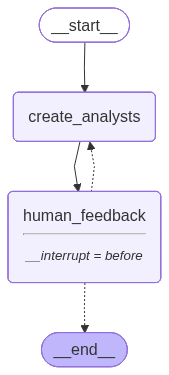

In [6]:
# ---------------------------------------------------
# 분석가 생성 그래프 조립 및 컴파일
# ---------------------------------------------------
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

# 그래프 빌더 생성
builder = StateGraph(GenerateAnalystsState)

# 노드 추가
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)

# 엣지 연결
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")

# 조건부 엣지: 피드백 있으면 재생성, 없으면 종료
builder.add_conditional_edges(
    "human_feedback",
    should_continue,
    ["create_analysts", END],
)

# 메모리 체크포인터 (HITL를 위해 필수)
memory = MemorySaver()

# 컴파일 시 interrupt_before로 human_feedback 전에 중단
analyst_graph = builder.compile(
    interrupt_before=["human_feedback"],
    checkpointer=memory,
)

# 그래프 흐름: START → create_analysts → human_feedback → (피드백 있으면 create_analysts 루프, 없으면 END)
# create_analysts: LLM이 연구 주제에 맞는 다양한 관점의 분석가 페르소나를 생성해요
# human_feedback: interrupt_before로 중단점 역할을 하며, 사용자가 분석가 구성을 검토해요
display(Image(analyst_graph.get_graph().draw_mermaid_png()))

### 2-1. 분석가 생성 실행 및 Human-in-the-Loop 체험

In [7]:
# ---------------------------------------------------
# 분석가 생성 그래프 실행 (첫 번째 중단점까지)
# ---------------------------------------------------
import uuid
from langchain_core.runnables import RunnableConfig

# 스레드 ID: 체크포인터가 상태를 저장하는 키예요
thread_id = str(uuid.uuid4())

config = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": thread_id},
)

# 연구 주제 설정 (원하는 주제로 변경해보세요)
topic = "Modular RAG가 기존 Naive RAG와 어떤 차이가 있는지, production 환경에서의 이점"
max_analysts = 3  # 생성할 분석가 수

inputs = {
    "topic": topic,
    "max_analysts": max_analysts,
}

# 그래프 실행 - human_feedback 노드 전에 자동으로 중단돼요
for chunk in analyst_graph.stream(inputs, config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n{'='*50}")
        print(f"노드: {node_name}")
        # ==================================================
        if node_name == "create_analysts" and "analysts" in node_output:
            for analyst in node_output["analysts"]:
                print(f"  이름: {analyst.name}")
                print(f"  역할: {analyst.role}")
                print(f"  소속: {analyst.affiliation}")
                print()


노드: create_analysts
  이름: Dr. Emily Chen
  역할: Machine Learning Researcher
  소속: Tech Research Institute

  이름: John Smith
  역할: Software Engineer
  소속: AI Innovations Lab

  이름: Dr. Mahmoud Al-Farsi
  역할: Data Scientist
  소속: Data Systems Analytics


노드: __interrupt__


In [8]:
# ---------------------------------------------------
# 현재 그래프 상태 확인
# ---------------------------------------------------
state = analyst_graph.get_state(config)

# 다음 실행할 노드 확인 - ('human_feedback',)이어야 해요
print("다음 노드:", state.next)

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


다음 노드: ('human_feedback',)


In [9]:
# ---------------------------------------------------
# Human-in-the-Loop: 피드백 주입
# ---------------------------------------------------
# update_state()로 human_feedback 노드의 역할을 대신해요
# as_node="human_feedback": 이 상태 업데이트가 human_feedback 노드에서 발생한 것처럼 처리해요

analyst_graph.update_state(
    config,
    {
        "human_analyst_feedback": "스타트업 창업자 관점의 분석가를 한 명 추가해주세요"
    },
    as_node="human_feedback",  # 피드백이 이 노드에서 발생한 것처럼 처리
)

# 피드백이 주입되었어요. 그래프를 재개합니다.

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


피드백이 주입되었어요. 그래프를 재개합니다.


In [10]:
# ---------------------------------------------------
# 피드백 반영 후 그래프 재개
# ---------------------------------------------------
# None을 입력으로 주면 중단된 지점부터 이어서 실행해요
for chunk in analyst_graph.stream(None, config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n{'='*50}")
        print(f"노드: {node_name}")
        # ==================================================
        if node_name == "create_analysts" and "analysts" in node_output:
            for analyst in node_output["analysts"]:
                print(f"  이름: {analyst.name}")
                print(f"  역할: {analyst.role}")
                print(f"  소속: {analyst.affiliation}")
                print()

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]



노드: create_analysts
  이름: Alex Kim
  역할: AI Research Analyst
  소속: Tech Innovation Consultants

  이름: Sara Thompson
  역할: Production Systems Architect
  소속: Data Systems Inc.

  이름: James Wong
  역할: Startup Founder and Innovator
  소속: Startup Founders Coalition


노드: __interrupt__


In [11]:
# ---------------------------------------------------
# 피드백 없이 종료하기
# ---------------------------------------------------
# human_analyst_feedback에 None을 주면 분석가 생성을 종료해요

analyst_graph.update_state(
    config,
    {"human_analyst_feedback": None},  # None → 재생성 없이 종료
    as_node="human_feedback",
)

# 마무리 실행
for chunk in analyst_graph.stream(None, config, stream_mode="updates"):
    pass

# 분석가 생성 완료!

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to 

분석가 생성 완료!


In [12]:
# ---------------------------------------------------
# 최종 분석가 목록 확인
# ---------------------------------------------------
final_analyst_state = analyst_graph.get_state(config)
analysts = final_analyst_state.values.get("analysts")

print(f"생성된 분석가 수: {len(analysts)}")
# ==================================================

for analyst in analysts:
    print(analyst.persona)
    # - - - - - - - - - - - - - - - - - - - - - - - - -

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


생성된 분석가 수: 3
Name: Alex Kim
Role: AI Research Analyst
Affiliation: Tech Innovation Consultants
Description: Alex focuses on the comparative performance of Modular RAG and Naive RAG methodologies. He analyzes various research papers and industry case studies to derive insights on how these models impact data retrieval and user interactions in AI applications.

- - - - - - - - - - - - - - - - - - - - - - - - - 
Name: Sara Thompson
Role: Production Systems Architect
Affiliation: Data Systems Inc.
Description: Sara specializes in the implementation of data retrieval systems in production environments. She evaluates the scalability and integration benefits of Modular RAG over Naive RAG, as well as its implications for operational efficiency and system maintenance.

- - - - - - - - - - - - - - - - - - - - - - - - - 
Name: James Wong
Role: Startup Founder and Innovator
Affiliation: Startup Founders Coalition
Description: James brings a startup perspective to the analysis of Modular RAG versus

## 3. 인터뷰 서브그래프 구성

각 분석가가 전문가를 인터뷰하는 서브그래프예요. 분석가가 질문을 생성하면, 웹 검색과 논문 검색을 **병렬**로 수행하여 전문가가 답변해요.

> 🔑 **핵심 개념**: `ask_question → (search_web + search_arxiv 병렬) → answer_question` 패턴이에요. 두 검색 노드가 동시에 실행되고, 둘 다 완료되면 답변 노드로 넘어가요. LangGraph는 같은 노드로 향하는 여러 엣지를 자동으로 병렬 처리해요.

> 💡 **실무 팁**: `Annotated[list, operator.add]`를 사용하면 병렬 노드의 결과를 자동으로 누적할 수 있어요. `context`가 그 예시예요.

In [13]:
# ---------------------------------------------------
# 인터뷰 상태(State) 및 검색 쿼리 모델 정의
# ---------------------------------------------------
import operator
from typing import Annotated
from langgraph.graph import MessagesState


# 인터뷰 서브그래프의 상태
class InterviewState(MessagesState):
    # 최대 질문-답변 턴 수
    max_num_turns: int
    # 검색된 문서 컨텍스트 (병렬 검색 결과를 누적)
    # Annotated[list, operator.add]: 여러 노드에서 추가되는 리스트를 자동 합산
    context: Annotated[list, operator.add]
    # 인터뷰를 수행하는 분석가
    analyst: Analyst
    # 완료된 인터뷰 텍스트
    interview: str
    # 작성된 보고서 섹션들
    sections: list


# 검색 쿼리를 구조화하는 Pydantic 모델
class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")


# 인터뷰 상태 및 검색 쿼리 모델 정의 완료

인터뷰 상태 및 검색 쿼리 모델 정의 완료


In [14]:
# ---------------------------------------------------
# 질문 생성 노드
# ---------------------------------------------------
# 분석가의 페르소나와 목표를 기반으로 전문가에게 질문을 생성해요

# 분석가 인터뷰 지시사항
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""


def generate_question(state: InterviewState):
    """분석가의 페르소나에 맞는 인터뷰 질문을 생성하는 노드예요"""

    analyst = state["analyst"]
    messages = state["messages"]

    # 분석가 목표로 시스템 메시지 구성
    system_message = question_instructions.format(goals=analyst.persona)

    # LLM으로 질문 생성
    question = llm.invoke(
        [SystemMessage(content=system_message)] + messages
    )

    return {"messages": [question]}

In [16]:
!uv add arxiv

Resolved 194 packages in 401ms                                       
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/11.65 KiB           
⠙ Preparing packages... (0/1)---------- 11.65 KiB/11.65 KiB         
Prepared 1 package in 27ms                                                        
Installed 3 packages in 5ms                                 
 + arxiv==3.0.0
 + feedparser==6.0.12
 + sgmllib3k==1.0.0


In [17]:
# ---------------------------------------------------
# 검색 도구 초기화
# ---------------------------------------------------
# Tavily: 최신 웹 정보 검색
# ArxivRetriever: 학술 논문 검색
from langchain_tavily import TavilySearch
from langchain_community.retrievers import ArxivRetriever

# 웹 검색 도구 (TAVILY_API_KEY 환경변수 필요)
tavily_search = TavilySearch(max_results=1)

# Arxiv 논문 검색 도구 (무료, API 키 불필요)
arxiv_retriever = ArxivRetriever(
    load_max_docs=1,           # 최대 문서 수
    load_all_available_meta=True,  # 메타데이터 포함
    get_full_documents=True,   # 전체 문서 로드
)

# 검색 도구 초기화 완료

검색 도구 초기화 완료


In [18]:
# ---------------------------------------------------
# 검색 쿼리 생성용 시스템 메시지
# ---------------------------------------------------
from langchain.messages import SystemMessage as SM

# 대화 내용을 보고 검색 쿼리를 생성하도록 지시해요
search_instructions = SM(
    content="""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
        
First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query"""
)


def search_web(state: InterviewState):
    """대화를 분석하여 웹 검색 쿼리를 생성하고 Tavily로 검색하는 노드예요"""

    # 대화 기반 검색 쿼리 구조화
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke(
        [search_instructions] + state["messages"]
    )

    # 웹 검색 실행
    # TavilySearch.invoke()는 {"results": [...], "query": ..., ...} 형태의 딕셔너리를 반환해요
    search_response = tavily_search.invoke(search_query.search_query)
    
    # results 키에서 문서 목록을 추출해요
    if isinstance(search_response, dict):
        search_docs = search_response.get("results", [])
    else:
        # 이미 리스트인 경우를 대비한 fallback
        search_docs = search_response

    # 검색 결과를 XML 형식으로 포맷팅
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    # context 리스트에 추가 (operator.add로 자동 합산)
    return {"context": [formatted_search_docs]}


def search_arxiv(state: InterviewState):
    """Arxiv에서 관련 학술 논문을 검색하는 노드예요"""

    # 대화 기반 검색 쿼리 구조화
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke(
        [search_instructions] + state["messages"]
    )

    try:
        # Arxiv 검색 실행
        arxiv_results = arxiv_retriever.invoke(search_query.search_query)

        # 메타데이터 포함 XML 형식으로 포맷팅
        formatted_search_docs = "\n\n---\n\n".join(
            [
                f'<Document source="{doc.metadata["entry_id"]}" '
                f'date="{doc.metadata.get("Published", "")}" '
                f'authors="{doc.metadata.get("Authors", "")}"/>\n'
                f'<Title>\n{doc.metadata["Title"]}\n</Title>\n\n'
                f'<Summary>\n{doc.metadata["Summary"]}\n</Summary>\n\n'
                f'<Content>\n{doc.page_content[:2000]}\n</Content>\n</Document>'
                for doc in arxiv_results
            ]
        )

        return {"context": [formatted_search_docs]}

    except Exception as e:
        # 검색 실패 시 빈 결과 반환 (전체 그래프가 중단되지 않도록)
        print(f"Arxiv 검색 오류: {str(e)}")
        return {"context": ["<Error>Arxiv 검색 결과를 가져오는데 실패했습니다.</Error>"]}

In [19]:
# ---------------------------------------------------
# 답변 생성, 인터뷰 저장, 섹션 작성 노드 정의
# ---------------------------------------------------
from langchain_core.messages import get_buffer_string, AIMessage

# 전문가 답변 생성 지시사항
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
"""


def generate_answer(state: InterviewState):
    """수집된 컨텍스트를 기반으로 전문가 답변을 생성하는 노드예요"""

    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]  # search_web + search_arxiv의 결과가 합산된 리스트

    # 분석가 목표와 검색 컨텍스트를 포함한 시스템 메시지
    system_message = answer_instructions.format(
        goals=analyst.persona,
        context=context
    )
    answer = llm.invoke(
        [SystemMessage(content=system_message)] + messages
    )

    # 메시지에 'expert' 이름 부여 (라우팅에서 구분용)
    answer.name = "expert"

    return {"messages": [answer]}


def save_interview(state: InterviewState):
    """완료된 인터뷰 메시지를 하나의 문자열로 변환하여 저장하는 노드예요"""

    messages = state["messages"]
    # get_buffer_string: 메시지 리스트를 대화 텍스트로 변환해요
    interview = get_buffer_string(messages)

    return {"interview": interview}


# 섹션 작성 지시사항 (구조화된 마크다운 형식)
section_writer_instructions = """You are an expert technical writer. 

Your task is to create a detailed and comprehensive section of a report based on interview content.

Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
Write the report following this structure:
a. Title (## header)
b. Summary (### header)  
c. Comprehensive analysis (### header)
d. Sources (### header)

Make your title engaging based upon the focus area of the analyst: 
{focus}

For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents

For the Comprehensive analysis section:
- Provide a detailed examination of the information from the source documents.
- Support your analysis with data, direct quotes, and examples from the source documents.
- Aim for at least 800 words to ensure the analysis is thorough.

In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths"""


def write_section(state: InterviewState):
    """인터뷰 결과를 구조화된 보고서 섹션으로 작성하는 노드예요"""

    context = state["context"]
    analyst = state["analyst"]

    # 분석가의 관심 분야를 반영한 섹션 작성
    system_message = section_writer_instructions.format(
        focus=analyst.description
    )
    section = llm.invoke(
        [SystemMessage(content=system_message)]
        + [HumanMessage(content=f"Use this source to write your section: {context}")]
    )

    # sections 리스트에 추가
    return {"sections": [section.content]}

In [20]:
# ---------------------------------------------------
# 인터뷰 라우팅 함수
# ---------------------------------------------------
# 최대 턴 수 도달 또는 인터뷰 종료 신호에 따라 분기해요

def route_messages(state: InterviewState, name: str = "expert"):
    """인터뷰 종료 여부를 판단하는 라우팅 함수예요"""

    messages = state["messages"]
    max_num_turns = state.get("max_num_turns", 2)  # 기본값: 2턴

    # 전문가('expert' 이름의 AI) 응답 수 카운트
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # 최대 턴 수 초과 시 인터뷰 저장으로 이동
    if num_responses >= max_num_turns:
        return "save_interview"

    # 분석가가 "Thank you so much for your help!" 라고 하면 종료
    last_question = messages[-2]  # 최근 분석가 질문
    if "Thank you so much for your help" in last_question.content:
        return "save_interview"

    # 아직 더 질문할 것이 있으면 계속
    return "ask_question"

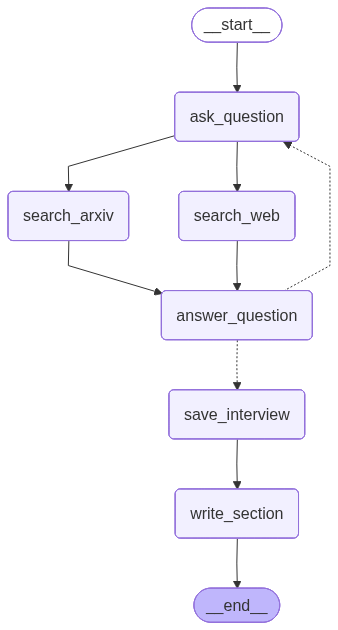

In [21]:
# ---------------------------------------------------
# 인터뷰 서브그래프 조립 및 컴파일
# ---------------------------------------------------
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver

# 인터뷰 그래프 빌더
interview_builder = StateGraph(InterviewState)

# 노드 추가
interview_builder.add_node("ask_question", generate_question)   # 분석가 질문 생성
interview_builder.add_node("search_web", search_web)             # 웹 검색 (병렬 1)
interview_builder.add_node("search_arxiv", search_arxiv)         # 논문 검색 (병렬 2)
interview_builder.add_node("answer_question", generate_answer)  # 전문가 답변
interview_builder.add_node("save_interview", save_interview)    # 인터뷰 저장
interview_builder.add_node("write_section", write_section)      # 섹션 작성

# 흐름 설정
interview_builder.add_edge(START, "ask_question")
# ask_question → 두 검색 노드로 분기 (병렬 실행)
interview_builder.add_edge("ask_question", "search_web")
interview_builder.add_edge("ask_question", "search_arxiv")
# 두 검색 완료 후 → 답변 생성 (자동 동기화)
interview_builder.add_edge("search_web", "answer_question")
interview_builder.add_edge("search_arxiv", "answer_question")
# 답변 후 라우팅: 계속 또는 종료
interview_builder.add_conditional_edges(
    "answer_question",
    route_messages,
    ["ask_question", "save_interview"],
)
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

# 서브그래프 컴파일 (체크포인터 포함)
interview_memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=interview_memory).with_config(
    run_name="Conduct Interviews"
)

# 그래프 흐름: START → ask_question → (search_web + search_arxiv 병렬) → answer_question → (route_messages 분기) → save_interview → write_section → END
# ask_question: 분석가 페르소나에 맞는 인터뷰 질문을 생성해요
# search_web + search_arxiv: 웹과 논문을 동시에 검색하여 컨텍스트를 수집해요
# answer_question: 수집된 컨텍스트로 전문가 답변을 생성해요
# route_messages: 최대 턴 초과 또는 종료 신호 시 save_interview로, 아니면 ask_question으로 루프해요
display(Image(interview_graph.get_graph().draw_mermaid_png()))

### 3-1. 단일 인터뷰 테스트

전체 시스템을 실행하기 전에 첫 번째 분석가와의 인터뷰를 단독으로 테스트해볼게요.

In [23]:
!uv add pymupdf

Resolved 195 packages in 68ms                                        
Installed 1 package in 9ms                                       ░░░░░░░░░░░░░░░░░░░░ [0/0] Installing wheels...                                 
 + pymupdf==1.27.2.2


In [24]:
# ---------------------------------------------------
# 단일 인터뷰 테스트
# ---------------------------------------------------
interview_config = RunnableConfig(
    recursion_limit=100,
    configurable={"thread_id": str(uuid.uuid4())},
)

# 첫 번째 분석가로 인터뷰 시작
first_analyst = analysts[0]
print(f"인터뷰 대상 분석가: {first_analyst.name} ({first_analyst.role})")
print()

# 인터뷰 시작 메시지
start_message = HumanMessage(
    content=f"So you said you were writing an article on {topic}?"
)

# 인터뷰 실행 (max_num_turns: 2턴만 진행)
for chunk in interview_graph.stream(
    {
        "analyst": first_analyst,
        "messages": [start_message],
        "max_num_turns": 2,
    },
    interview_config,
    stream_mode="updates",
):
    for node_name, node_output in chunk.items():
        print(f"[{node_name}] 실행 완료")

# 단일 인터뷰 완료!

인터뷰 대상 분석가: Alex Kim (AI Research Analyst)

[ask_question] 실행 완료
[search_web] 실행 완료
[search_arxiv] 실행 완료
[answer_question] 실행 완료
[ask_question] 실행 완료
[search_web] 실행 완료
[search_arxiv] 실행 완료
[answer_question] 실행 완료
[save_interview] 실행 완료
[write_section] 실행 완료

단일 인터뷰 완료!


In [25]:
# ---------------------------------------------------
# 인터뷰 결과로 생성된 보고서 섹션 확인
# ---------------------------------------------------
from IPython.display import Markdown

interview_final_state = interview_graph.get_state(interview_config)
first_section = interview_final_state.values.get("sections", [""])[0]

# 생성된 보고서 섹션 미리보기 (앞 500자):
print(first_section[:500])

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


생성된 보고서 섹션 미리보기 (앞 500자):
## Comparative Analysis of Modular RAG and Naive RAG Methodologies in AI Applications

### Summary

Retrieval-augmented generation (RAG) represents a significant advancement in harnessing large language models (LLMs) for knowledge-intensive tasks. By integrating retrieval mechanisms, RAG aims to enhance the performance and reliability of LLMs, particularly in complex reasoning scenarios. Recent interviews and research have unveiled the emergence of two distinct methodologies: Modular RAG and Nai


## 4. 전체 연구 그래프 (Map-Reduce 병렬 인터뷰)

이제 모든 분석가 인터뷰를 동시에 실행하는 전체 연구 그래프를 구성해요. `Send()` 문법은 앞 장에서 이미 다뤘으므로, 여기서는 **분석가 목록을 병렬 인터뷰 실행으로 바꾸는 Map-Reduce 적용**에 집중합니다.

> 🎯 **강의 포인트**: 분석가가 3명이든 10명이든 그래프 구조를 바꾸지 않습니다. `state["analysts"]`를 순회해 `Send("conduct_interview", ...)` 목록을 만들고, 결과 섹션은 `Annotated[list, operator.add]`로 합산해요.


In [26]:
# ---------------------------------------------------
# 전체 연구 그래프의 상태(State) 정의
# ---------------------------------------------------
import operator
from typing import List, Annotated
from typing_extensions import TypedDict


class ResearchGraphState(TypedDict):
    # 연구 주제
    topic: str
    # 생성할 분석가의 최대 수
    max_analysts: int
    # 사용자 피드백
    human_analyst_feedback: str
    # 분석가 목록
    analysts: List[Analyst]
    # 각 인터뷰에서 생성된 섹션들 (Send()로 병렬 처리된 결과를 자동 합산)
    sections: Annotated[list, operator.add]
    # 보고서 구성 요소
    introduction: str   # 서론
    content: str        # 본문 (인사이트)
    conclusion: str     # 결론
    final_report: str   # 최종 보고서

In [27]:
# ---------------------------------------------------
# Send() API를 이용한 병렬 인터뷰 시작 함수
# ---------------------------------------------------
# Send()는 지정된 노드에 여러 다른 상태를 동시에 전송해요
from langgraph.types import Send  # V1에서는 langgraph.types에서 import


def initiate_all_interviews(state: ResearchGraphState):
    """모든 분석가의 인터뷰를 병렬로 시작하거나, 피드백이 있으면 재생성하는 함수예요"""

    human_analyst_feedback = state.get("human_analyst_feedback")

    if human_analyst_feedback:
        # 피드백이 있으면 분석가 재생성 노드로 돌아가요
        return "create_analysts"

    # 피드백이 없으면 모든 분석가에게 인터뷰를 동시에 시작해요
    # Send("노드이름", {상태 딕셔너리}) 형식으로 사용해요
    topic = state["topic"]
    return [
        Send(
            "conduct_interview",  # 이 노드에 전송
            {
                "analyst": analyst,  # 각 분석가별 다른 입력
                "messages": [
                    HumanMessage(
                        content=f"So you said you were writing an article on {topic}?"
                    )
                ],
            },
        )
        for analyst in state["analysts"]  # 분석가 수만큼 병렬 실행 생성
    ]

In [28]:
# ---------------------------------------------------
# 보고서 작성 노드들 정의
# ---------------------------------------------------
# 보고서 본문 작성 지시사항
report_writer_instructions = """You are a technical writer creating a report on this overall topic:

{topic}

You have a team of analysts. Each analyst has done two things:
1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task:
1. You will be given a collection of memos from your analysts.  
2. Carefully review and analyze the insights from each memo.  
3. Consolidate these insights into a detailed and comprehensive summary.

To format your report:
1. Use markdown formatting.
2. Include no pre-amble for the report.
3. Use no sub-heading.
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos (e.g., [1] or [2]).
7. Create a final, consolidated list of sources under ## Sources.

Here are the memos from your analysts to build your report from:

{context}"""


def write_report(state: ResearchGraphState):
    """모든 분석가 메모를 통합하여 보고서 본문(Insights)을 작성하는 노드예요"""

    sections = state["sections"]  # Send()로 수집된 모든 섹션
    topic = state["topic"]

    # 모든 섹션을 하나의 문자열로 합쳐요
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    system_message = report_writer_instructions.format(
        topic=topic,
        context=formatted_str_sections
    )
    report = llm.invoke(
        [SystemMessage(content=system_message)]
        + [HumanMessage(content="Write a report based upon these memos.")]
    )
    return {"content": report.content}


# 서론·결론 작성 지시사항
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 200 words, crisply previewing (for introduction), or recapping (for conclusion) all of the sections of the report.

Use markdown formatting.

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header.

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""


def write_introduction(state: ResearchGraphState):
    """보고서의 서론을 작성하는 노드예요"""

    sections = state["sections"]
    topic = state["topic"]
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    instructions = intro_conclusion_instructions.format(
        topic=topic,
        formatted_str_sections=formatted_str_sections
    )
    intro = llm.invoke(
        [instructions]
        + [HumanMessage(content="Write the report introduction")]
    )
    return {"introduction": intro.content}


def write_conclusion(state: ResearchGraphState):
    """보고서의 결론을 작성하는 노드예요"""

    sections = state["sections"]
    topic = state["topic"]
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    instructions = intro_conclusion_instructions.format(
        topic=topic,
        formatted_str_sections=formatted_str_sections
    )
    conclusion = llm.invoke(
        [instructions]
        + [HumanMessage(content="Write the report conclusion")]
    )
    return {"conclusion": conclusion.content}


def finalize_report(state: ResearchGraphState):
    """서론, 본문, 결론을 조립하여 최종 보고서를 완성하는 노드예요"""

    content = state["content"]

    # 'Insights' 헤더 제거하여 서론 뒤에 깔끔하게 붙이기
    if content.startswith("## Insights"):
        content = content.strip("## Insights")

    # 소스 섹션 분리
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except Exception:
            sources = None
    else:
        sources = None

    # 최종 보고서 조립
    final_report = (
        state["introduction"]
        + "\n\n---\n\n## Main Idea\n\n"
        + content
        + "\n\n---\n\n"
        + state["conclusion"]
    )
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources

    return {"final_report": final_report}

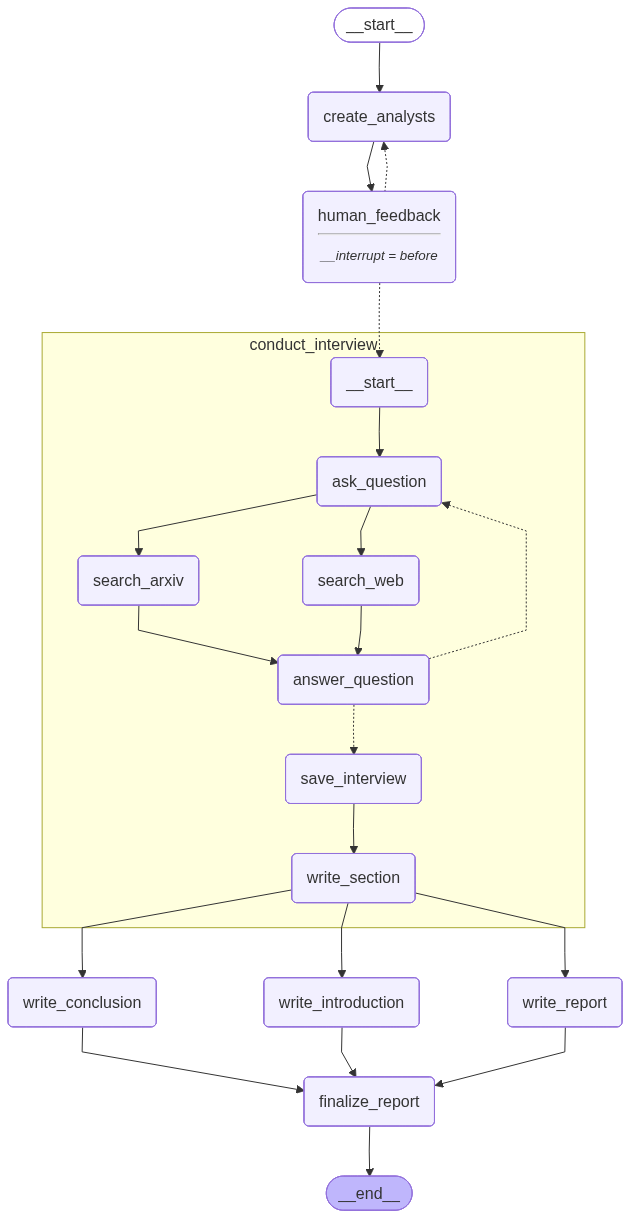

In [29]:
# ---------------------------------------------------
# 전체 연구 그래프 조립 및 컴파일
# ---------------------------------------------------
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver

# 전체 연구 그래프 빌더
research_builder = StateGraph(ResearchGraphState)

# --- 노드 추가 ---
# 분석가 생성 노드 (HITL 포함)
research_builder.add_node("create_analysts", create_analysts)
research_builder.add_node("human_feedback", human_feedback)
# 인터뷰 서브그래프를 단일 노드로 등록
research_builder.add_node("conduct_interview", interview_builder.compile())
# 보고서 작성 노드들
research_builder.add_node("write_report", write_report)
research_builder.add_node("write_introduction", write_introduction)
research_builder.add_node("write_conclusion", write_conclusion)
research_builder.add_node("finalize_report", finalize_report)

# --- 엣지 연결 ---
research_builder.add_edge(START, "create_analysts")
research_builder.add_edge("create_analysts", "human_feedback")

# human_feedback → 피드백 있으면 재생성, 없으면 Send()로 병렬 인터뷰 시작
research_builder.add_conditional_edges(
    "human_feedback",
    initiate_all_interviews,
    ["create_analysts", "conduct_interview"],
)

# 모든 인터뷰 완료 후 → 서론/본문/결론 병렬 작성
research_builder.add_edge("conduct_interview", "write_report")
research_builder.add_edge("conduct_interview", "write_introduction")
research_builder.add_edge("conduct_interview", "write_conclusion")

# 세 섹션 모두 완료 후 → 최종 보고서 조립
research_builder.add_edge(
    ["write_conclusion", "write_report", "write_introduction"],
    "finalize_report",
)
research_builder.add_edge("finalize_report", END)

# 컴파일 (human_feedback 전에 중단, 체크포인터)
research_memory = MemorySaver()
research_graph = research_builder.compile(
    interrupt_before=["human_feedback"],
    checkpointer=research_memory,
)

# 전체 그래프 시각화 (xray=True로 서브그래프까지)
display(Image(research_graph.get_graph(xray=True).draw_mermaid_png()))

## 5. 전체 연구 워크플로우 실행

이제 전체 파이프라인을 실행해볼게요. 분석가 생성 → Human-in-the-Loop → 병렬 인터뷰 → 보고서 작성 순서로 진행돼요.

> ⚠️ **자주 하는 실수**: `recursion_limit`을 충분히 크게 설정해야 해요. 각 분석가 인터뷰마다 여러 노드를 실행하고, 서브그래프의 노드도 카운트되기 때문에 분석가 수 × 턴 수 × 노드 수가 합산돼요.

In [30]:
# ---------------------------------------------------
# 전체 연구 워크플로우 실행 (Step 1: 분석가 생성)
# ---------------------------------------------------
# ============================================================
# TODO: 연구 주제를 바꿔서 다른 주제로 보고서를 생성해보세요!
# 힌트: topic 변수를 원하는 연구 주제로 변경해요
# 예상 결과: 해당 주제에 맞는 3명의 전문가 분석가가 생성돼요
# ============================================================
research_topic = "LangGraph와 LangChain의 차이점, 그리고 에이전트 개발에서 LangGraph를 사용해야 하는 이유"
research_max_analysts = 3  # 더 많은 분석가를 생성하려면 이 값을 늘리세요 (실행 시간 증가)

# 연구 그래프용 config (recursion_limit을 충분히 크게 설정)
research_config = RunnableConfig(
    recursion_limit=200,  # 분석가 3명 × 턴 2개 × 여러 노드 = 많은 재귀 필요
    configurable={"thread_id": str(uuid.uuid4())},
)

research_inputs = {
    "topic": research_topic,
    "max_analysts": research_max_analysts,
}

# 첫 번째 실행: human_feedback 노드 전에 자동 중단
# Step 1: 분석가 생성 중...
for chunk in research_graph.stream(research_inputs, research_config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"[{node_name}] 실행")
        if node_name == "create_analysts" and "analysts" in node_output:
            # 생성된 분석가:
            for a in node_output["analysts"]:
                print(f"  - {a.name}: {a.role}")
        if node_name == "__interrupt__":
            # [중단] Human-in-the-Loop 대기 중...
            pass

Step 1: 분석가 생성 중...
[create_analysts] 실행

생성된 분석가:
  - Dr. Clara Nguyen: AI Framework Specialist
  - Mark Chen: Agent Development Expert
  - Sophia Martinez: Product Strategy Analyst
[__interrupt__] 실행

[중단] Human-in-the-Loop 대기 중...


In [31]:
# ---------------------------------------------------
# Step 2: 분석가 검토 후 피드백 없이 진행
# ---------------------------------------------------
# 분석가 구성에 만족하면 human_analyst_feedback에 None을 설정해요
# 피드백을 추가하려면: {"human_analyst_feedback": "원하는 피드백 내용"}

research_graph.update_state(
    research_config,
    {"human_analyst_feedback": None},  # None = 피드백 없이 진행
    as_node="human_feedback",
)

# Step 2: 피드백 없이 인터뷰를 시작합니다.

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


Step 2: 피드백 없이 인터뷰를 시작합니다.


In [32]:
# ---------------------------------------------------
# Step 3: 병렬 인터뷰 + 보고서 작성 실행
# ---------------------------------------------------
# 이 셀은 실행에 시간이 걸려요 (분석가 수 × 턴 수만큼)
# 웹 검색 API 호출도 포함되어 있어요

# Step 3: 병렬 인터뷰 및 보고서 작성 중...
# (Tavily 웹 검색 + Arxiv 논문 검색이 각 인터뷰에서 실행돼요)
print()

completed_nodes = []
for chunk in research_graph.stream(None, research_config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        if node_name not in completed_nodes:
            completed_nodes.append(node_name)
            print(f"  [{node_name}] 완료")

# Step 3 완료!

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to 

Step 3: 병렬 인터뷰 및 보고서 작성 중...
(Tavily 웹 검색 + Arxiv 논문 검색이 각 인터뷰에서 실행돼요)

Arxiv 검색 오류: module 'fitz' has no attribute 'fitz'
  [conduct_interview] 완료
  [write_introduction] 완료
  [write_conclusion] 완료
  [write_report] 완료
  [finalize_report] 완료

Step 3 완료!


In [33]:
# ---------------------------------------------------
# Step 4: 최종 보고서 출력
# ---------------------------------------------------
from IPython.display import Markdown, display as ipy_display

# 최종 상태에서 보고서 가져오기
research_final_state = research_graph.get_state(research_config)
final_report = research_final_state.values.get("final_report")

# 최종 보고서가 완성되었어요!
print(f"보고서 길이: {len(final_report)} 글자")
# ============================================================

# 마크다운으로 렌더링
ipy_display(Markdown(final_report))

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


최종 보고서가 완성되었어요!
보고서 길이: 7179 글자




# Unraveling the Differences Between LangGraph and LangChain in AI Agent Development

## Introduction

The rapid evolution of artificial intelligence (AI) has ushered in transformative approaches in fields like machine translation (MT). This report delves into the nuances that distinguish LangGraph from LangChain, focusing on the innovative applications of these frameworks in developing intelligent agents. Recent advancements highlight LangGraph's modular architecture, which streamlines workflow management and enhances the creation of specialized agents capable of performing complex translation tasks with remarkable efficiency. 

In a landscape where maintaining context and accuracy in multilingual interactions is paramount, the integration of large language models (LLMs) like GPT-4o makes LangGraph a powerful ally in addressing these challenges. The exploration reveals how agents such as TranslateEnAgent and TranslateFrenchAgent exemplify LangGraph's strengths in fostering collaboration and improving task execution. 

Furthermore, we examine empirical studies demonstrating the significant enhancements in translation accuracy and scalability achieved through LangGraph's architecture. This report ultimately posits that LangGraph not only advances translation workflows but also sets the stage for broader applications in AI-driven solutions, making a compelling case for its adoption in future agent development initiatives.

---

## Main Idea



The evolution of artificial intelligence, particularly in the domain of machine translation (MT), has led to the emergence of innovative frameworks like LangGraph and LangChain. This report synthesizes various perspectives on the distinctions between these two platforms and argues for the advantages of employing LangGraph in agent development.

LangGraph is noted for its modular architecture that significantly enhances the efficiency of task execution in MT. Unlike LangChain, which provides a foundational layer for utilizing large language models (LLMs), LangGraph specifically builds upon this foundation by allowing the creation of specialized agents for handling diverse translation tasks. Each agent, such as TranslateEnAgent for English and TranslateFrenchAgent for French, operates independently yet can collaborate dynamically, significantly improving both translation accuracy and the management of context across user interactions.

The graph-based architecture of LangGraph simplifies workflow management, allowing for intelligent routing of user inputs and efficient processing. This is particularly crucial for MT systems that must handle complex translation scenarios while maintaining dialogue continuity. The ability for agents to work collaboratively and share resources fosters an environment of enhanced communication, which ultimately leads to more coherent and relevant output.

Furthermore, the modular design of LangGraph allows it to maintain real-time context retention, a feature where traditional systems often fall short. This enables seamless interaction across multiple languages, preserving the nuances and subtleties of communication during multi-lingual conversations. In contrast, LangChain’s structure may not support such intricate interactions as effectively, as it lacks the advanced dynamic state management feature present in LangGraph.

Experimental studies presented in the research underscore the pronounced improvements in translation accuracy and overall process efficiency attributed to LangGraph. The integration of open-source community support enables developers to innovate continuously, thus creating a robust ecosystem that can adapt to evolving linguistic challenges. Such community involvement is a strategic advantage for LangGraph over LangChain, as it fosters a spirit of collaboration and shared knowledge among developers.

Additionally, the synergy created by incorporating frameworks like CrewAI enhances LangGraph’s capabilities in multi-agent systems. This collaboration optimizes task management and resource allocation, allowing agents to tackle complex challenges in parallel rather than sequentially. As a result, LangGraph not only meets current market demands for MT solutions but is also positioned to address future needs in AI-driven applications.

The transformative impact of LangGraph within the landscape of AI and machine translation emphasizes its novel approach to agent-based architectures. By embracing modularity and embracing advanced capabilities derived from LLMs, LangGraph sets itself apart as a forward-thinking solution that can redefine how intelligent systems interact with language and perform translation tasks. The framework's ability to interlink specialized agents provides avenues for scalability and enhanced performance in AI applications, ensuring a competitive edge in a rapidly advancing technological environment.


---

## Conclusion

In conclusion, the exploration of LangGraph reveals a groundbreaking shift in the realm of machine translation and AI agent applications. As detailed throughout this report, LangGraph's modular architecture significantly enhances the capabilities of AI agents, enabling specialized functionalities that streamline translation tasks and improve context retention. By leveraging large language models such as GPT-4o, agents like TranslateEnAgent and TranslateFrenchAgent can deliver precise and contextually relevant translations, which mark a substantial advancement over traditional systems.

The findings underscore the transformative potential of LangGraph in fostering collaborative agent interactions and automated workflows. The integration with frameworks like CrewAI further amplifies its capabilities, resulting in more efficient task management, feedback loops, and scalability. Empirical results demonstrate LangGraph’s superiority in enhancing multilingual translation efficiency, positioning it as a vital player in the competitive AI landscape.

Ultimately, LangGraph not only addresses existing challenges in machine translation but sets the stage for innovative future developments in intelligent systems. By embracing modularity and community-driven evolution, LangGraph stands poised to redefine the possibilities within AI-driven solutions, paving the way for advanced collaboration in a rapidly evolving technological environment. This positions it as a critical tool for developers and organizations aiming to maintain a competitive edge in the AI domain.

## Sources
1. Wang, J., & Duan, Z. (2024). *Agent AI with LangGraph: A Modular Framework for Enhancing Machine Translation Using Large Language Models*. Available at: [http://arxiv.org/abs/2412.03801v1](http://arxiv.org/abs/2412.03801v1)
2. Duan, Z., & Wang, J. (2024). *Exploration of LLM Multi-Agent Application Implementation Based on LangGraph+CrewAI*. Available at: [http://arxiv.org/abs/2411.18241v1](http://arxiv.org/abs/2411.18241v1)
3. Wang, J., & Duan, Z. (2024). *Intelligent Spark Agents: A Modular LangGraph Framework for Scalable, Visualized, and Enhanced Big Data Machine Learning Workflows*. Available at: [http://arxiv.org/abs/2412.01490v4](http://arxiv.org/abs/2412.01490v4)

## 6. 생성된 분석가 목록 및 섹션 요약 확인

In [34]:
# ---------------------------------------------------
# 생성된 분석가 및 인터뷰 섹션 요약
# ---------------------------------------------------
final_analysts = research_final_state.values.get("analysts", [])
final_sections = research_final_state.values.get("sections", [])

print(f"분석가 수: {len(final_analysts)}")
print(f"생성된 섹션 수: {len(final_sections)}")
print()

# 각 분석가와 해당 섹션 요약
for i, (analyst, section) in enumerate(zip(final_analysts, final_sections), 1):
    print(f"[분석가 {i}] {analyst.name} ({analyst.role})")
    # 섹션의 첫 200자만 미리보기
    print(f"  섹션 미리보기: {section[:200].strip()}...")
    print()

분석가 수: 3
생성된 섹션 수: 3

[분석가 1] Dr. Clara Nguyen (AI Framework Specialist)
  섹션 미리보기: ## Deep Dive into AI Frameworks: Evaluating LangGraph's Distinctions from LangChain

### Summary

The dynamic field of artificial intelligence (AI) is increasingly acknowledging the importance of modu...

[분석가 2] Mark Chen (Agent Development Expert)
  섹션 미리보기: ## Enhancing Machine Translation with Modular Agent AI: Insights from LangGraph

### Summary
The recent advancements in artificial intelligence (AI), particularly in the realm of language processing,...

[분석가 3] Sophia Martinez (Product Strategy Analyst)
  섹션 미리보기: ## Exploring Competitive Advantages of LangGraph in AI Agent Applications

### Summary
As artificial intelligence technology rapidly evolves, understanding market trends and leveraging strategic innov...



## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **STORM 패턴**: 다양한 관점의 분석가 페르소나를 생성하여 더 풍부한 연구 결과를 얻는 멀티 에이전트 접근법이에요
- **구조화 출력 적용**: Part 05에서 배운 Pydantic + `with_structured_output()`을 분석가 페르소나 생성에 적용했어요
- **HITL 적용**: Part 02에서 배운 `interrupt_before` + `update_state(as_node=...)`로 분석가 생성 과정에 사용자가 개입할 수 있게 했어요
- **Send() Map-Reduce 적용**: Part 02/03에서 배운 `Send`를 여러 독립 인터뷰 병렬 실행과 섹션 집계에 적용했어요
- **병렬 검색**: `ask_question → (search_web + search_arxiv 동시) → answer_question` 패턴으로 웹과 논문을 동시 검색해요
- **서브그래프 재사용**: `interview_builder.compile()`을 `add_node()`에 직접 전달하여 인터뷰 흐름을 재사용했어요
- **보고서 조립**: 서론 · 본문 · 결론을 병렬로 작성한 후 `finalize_report`에서 하나의 마크다운 보고서로 통합해요


## 다음 노트북 예고

다음 `04-Agent-Simulation.ipynb`에서는 **LLM으로 가상 고객을 만들어 챗봇을 자동 테스트**하는 기법을 배워요. 수동으로 하나씩 대화하지 않고, 시나리오(환불·분실·지연 등)별로 가상 고객 LLM을 생성해 자동으로 대화를 진행시키고 결과를 분석해요. `_swap_roles`로 두 LLM이 역할을 혼동하지 않게 하는 트릭이 핵심이에요.

<!-- AUTOPILOT_CREATE_AGENT_DEEP_AGENT_APPENDIX -->
## 보강: `create_deep_agent`로 Deep Research Agent를 하네스화하기

### 참고 공식 문서
- [Build a deep research agent](https://docs.langchain.com/oss/python/deepagents/deep-research)
- [Deep Agents overview](https://docs.langchain.com/oss/python/deepagents/overview)

본문의 STORM 구현은 분석가 생성, 인터뷰 서브그래프, `Send()` 기반 병렬 Map-Reduce를 직접 구현합니다. 덕분에 LangGraph의 병렬 실행과 HITL을 아주 명확하게 볼 수 있어요.

한편 공식 Deep Agents의 deep research 문서는 같은 문제를 더 높은 수준의 하네스로 풀어요. 핵심은 `create_deep_agent`에 **연구 코디네이터 프롬프트**와 **researcher 서브에이전트**를 전달하는 것입니다.

Deep Agents 방식으로 바꾸면 다음이 쉬워집니다.

- `write_todos`로 연구 계획을 자동 관리
- `task` 도구로 researcher 서브에이전트에게 하위 주제 위임
- 파일 도구로 `/research_request.md`, `/final_report.md` 같은 중간 산출물 저장
- 긴 연구 과정에서 컨텍스트 자동 압축과 파일 기반 맥락 유지
- 동기 실행뿐 아니라 `stream(..., stream_mode="updates")`로 진행 상황 표시

즉, 본문의 STORM 그래프는 **연구 워크플로우의 내부 원리 학습용**, 아래 방식은 **복잡한 리서치 앱을 빠르게 제품화하기 위한 시작점**으로 사용할 수 있어요.


In [ ]:
# ============================================================
# 선택 실행: create_deep_agent 기반 Deep Research Agent
# ============================================================
# Tavily/Arxiv API와 모델 API 키가 준비된 뒤 True로 바꾸세요.
RUN_CREATE_DEEP_RESEARCH_APPENDIX = False

if RUN_CREATE_DEEP_RESEARCH_APPENDIX:
    from datetime import datetime
    import arxiv
    from deepagents import create_deep_agent
    from langchain.chat_models import init_chat_model
    from langchain.tools import tool
    from langchain_tavily import TavilySearch

    # --------------------------------------------------------
    # 1) 연구 도구 정의
    # --------------------------------------------------------
    tavily_search = TavilySearch(max_results=5)

    @tool(parse_docstring=True)
    def search_arxiv_papers(query: str, max_results: int = 3) -> str:
        """Search arXiv papers and return concise citation candidates.

        Args:
            query: Research query for arXiv.
            max_results: Maximum number of papers to return.
        """
        client = arxiv.Client()
        search = arxiv.Search(
            query=query,
            max_results=max_results,
            sort_by=arxiv.SortCriterion.Relevance,
        )
        papers = []
        for paper in client.results(search):
            papers.append(f"- {paper.title}\n  URL: {paper.entry_id}\n  Summary: {paper.summary[:500]}")
        return "\n".join(papers) if papers else "No arXiv results found."

    # --------------------------------------------------------
    # 2) researcher 서브에이전트
    # --------------------------------------------------------
    # 공식 Deep Research 예제처럼 메인 에이전트는 직접 조사하지 않고,
    # researcher에게 하위 연구 질문을 위임하도록 지시해요.
    current_date = datetime.now().strftime("%Y-%m-%d")
    researcher = {
        "name": "research-agent",
        "description": "웹과 논문을 검색해 하나의 세부 연구 질문에 대한 근거를 수집합니다.",
        "system_prompt": f"""
You are a research subagent. Today is {current_date}.
Research exactly one focused question at a time.
Return concise findings with source URLs and uncertainty notes.
Do not write the final report; only return evidence for the coordinator.
""",
        "tools": [tavily_search, search_arxiv_papers],
    }

    # --------------------------------------------------------
    # 3) 연구 코디네이터 프롬프트
    # --------------------------------------------------------
    research_workflow = """
You are a deep research coordinator.
For every research request:
1. Use write_todos to create a research plan.
2. Save the original request to /research_request.md.
3. Delegate focused research tasks to research-agent using the task tool.
4. Synthesize all findings into a structured Korean report.
5. Save the final report to /final_report.md.
6. Verify that the report answers the original request and cites sources.
"""

    model = init_chat_model("openai:gpt-4o-mini", temperature=0)
    deep_research_agent = create_deep_agent(
        model=model,
        tools=[tavily_search, search_arxiv_papers],
        system_prompt=research_workflow,
        subagents=[researcher],
    )

    # --------------------------------------------------------
    # 4) 실행 예시
    # --------------------------------------------------------
    result = deep_research_agent.invoke({
        "messages": [{
            "role": "user",
            "content": "LangGraph v1에서 장기 실행 에이전트를 설계할 때 중요한 패턴을 조사해줘.",
        }]
    })

    print(result["messages"][-1].content)
